In [8]:
# 🔹 Imports
import pandas as pd
import numpy as np
import re
from collections import defaultdict
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn import metrics

In [9]:
# 🔹 Load Dataset
dataset = pd.read_csv("C:/Users/user/Downloads/TwitterBot/TwitterBot/Dataset/kaggle_tweets.csv")   # change file path
dataset.head()

,id,id_str,screen_name,location,description,url,followers_count,friends_count,listedcount,created_at,favourites_count,verified,statuses_count,lang,status,default_profile,default_profile_image,has_extended_profile,name,bot
0,8.160000e+17,"""815745789754417152""","""HoustonPokeMap""","""Houston, TX""","""Rare and strong PokŽmon in Houston, TX. See m...","""https://t.co/dnWuDbFRkt""",1291,0,10,"""Mon Jan 02 02:25:26 +0000 2017""",0,False,78554,"""en""","{\r ""created_at"": ""Sun Mar 12 15:44:04 +0...",True,False,False,"""Houston PokŽ Alert""",1
1,4.843621e+09,4843621225,kernyeahx,"Templeville town, MD, USA",From late 2014 Socium Marketplace will make sh...,NaN,1,349,0,2/1/2016 7:37,38,False,31,en,NaN,True,False,False,Keri Nelson,1
2,4.303727e+09,4303727112,mattlieberisbot,NaN,"Inspired by the smart, funny folks at @replyal...",https://t.co/P1e1o0m4KC,1086,0,14,Fri Nov 20 18:53:22 +0000 2015,0,False,713,en,"{'retweeted': False, 'is_quote_status': False,...",True,False,False,Matt Lieber Is Bot,1
3,3.063139e+09,3063139353,sc_papers,NaN,NaN,NaN,33,0,8,2/25/2015 20:11,0,False,676,en,Construction of human anti-tetanus single-chai...,True,True,False,single cell papers,1
4,2.955142e+09,2955142070,lucarivera16,"Dublin, United States",Inspiring cooks everywhere since 1956.,NaN,11,745,0,1/1/2015 17:44,146,False,185,en,NaN,False,False,False,lucarivera16,1


In [10]:
# 🔹 Bot keyword list
words = ['bot','cannabis','tweet me','mishear','follow me','updates','every','gorilla','forget']

In [11]:
# 🔹 Function to calculate frequency
def getFrequency(bow):
    count = 0
    for w in words:
        if w in bow:
            count += bow[w]
    return count

In [12]:
# 🔹 Rule-based Bot Detection
users = []

for i in range(len(dataset)):
    screen = dataset.iloc[i]['screen_name']
    status = dataset.iloc[i]['status']
    name = dataset.iloc[i]['name']
    
    followers = int(dataset.iloc[i]['followers_count'])
    listed = int(dataset.iloc[i]['listedcount'])
    verified = dataset.iloc[i]['verified']

    if not verified:
        data = str(screen) + " " + str(name) + " " + str(status)
        data = re.findall(r'\w+', data.lower())

        bow = defaultdict(int)
        for word in data:
            bow[word] += 1

        frequency = getFrequency(bow)

        if frequency > 0 and listed < 16000 and followers < 200:
            users.append(screen)

print("Possible Bot Users:", users)

Possible Bot Users: ['ecin_gnihtaseod', 'everyMTGlegend', 'NESGarbageBot', 'forestgen', 'crystalliser', 'BoazimBot', 'aura_mazon', 'emojicheer', 'EuphemismBot', 'IFClueBot', 'TahoeChains', 'SadisticMedic_', 'McdanielArmijo', 'msxs_2016', 'PentatonicBot', 'everywordcup', 'MuscleStemCell', 'donalddrumpfbot', 'attribot', 'litts_mccarlie', 'SunsetGenerator', 'MusicmakerBot', 'a_travel_bot', 'TermsofSbot', 'starnearyou', 'OldLSystemBot', 'GilgameshTweets', 'PenryParmelee', 'bot_things', 'netflixtaglines', 'bouquetbot', 'pizzaclones', 'NaiveAnswers', 'BotMtGFlavor', 'gorillacities', 'theDesireBot', 'VillanelleBot', 'ideabot', 'botsummittalks', 'TurnsOutBot', 'randomRTBot', 'plzasm', 'randomchordbot', 'youareherebot', 'wearable_things', 'haikuthegibson', 'MusicReviewBot', 'BecauseBot', 'lawandorderexo', 'EquestrianBot', 'fluffmaster7000', 'TinyCrossword', 'TransxnNoiseBot', 'CointraqBot', '_posibot', 'DifferenceJoke', 'abotcalledquest', 'mnemosynetron', 'yes_ofc', 'justdidathing', 'spiraesthe

In [13]:
# 🔹 Prepare ML Data
X = dataset[['followers_count','friends_count','listedcount','favourites_count','statuses_count','verified']]
Y = dataset['bot']

In [14]:
# 🔹 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [15]:
# 🔹 Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
# 🔹 Prediction
pred = model.predict(X_test)

In [17]:
# 🔹 Evaluation
accuracy = accuracy_score(y_test, pred) * 100
precision = precision_score(y_test, pred) * 100
recall = recall_score(y_test, pred) * 100
f1 = f1_score(y_test, pred)
auc = roc_auc_score(y_test, pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("AUC:", auc)

Accuracy: 70.35714285714286
Precision: 62.558139534883715
Recall: 98.17518248175182
F1 Score: 0.7642045454545454
AUC: 0.7094073809402277


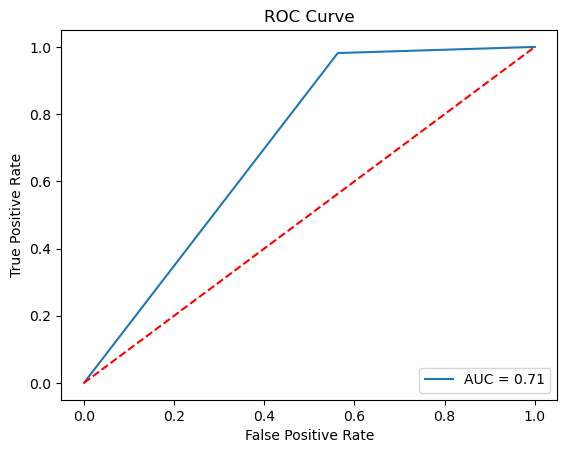

In [18]:
# 🔹 ROC Curve
fpr, tpr, _ = metrics.roc_curve(y_test, pred)
roc_auc = metrics.auc(fpr, tpr)

plt.title('ROC Curve')
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

In [19]:
# 🔹 Module 3 (URL Feature)

urls = []
for i in range(len(dataset)):
    tweets = dataset.iloc[i]['status']
    if 'http' in str(tweets):
        urls.append(1)
    else:
        urls.append(0)

dataset['URLS'] = urls

X2 = dataset[['followers_count','friends_count','listedcount','favourites_count','statuses_count','verified','URLS']]
Y2 = dataset['bot']

X_train, X_test, y_train, y_test = train_test_split(X2, Y2, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("\nWith URL Feature:")
print("Accuracy:", accuracy_score(y_test, pred) * 100)


With URL Feature:
Accuracy: 68.92857142857143


C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
